In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Module 2: Data Exploration and Data Preprocessing


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import albumentations as A


In [ ]:
# Simulated SAR image (single-channel)
sar_image = np.random.randint(0, 255, (512, 512), dtype=np.uint8)

# Simulated oil spill mask
mask = np.zeros((512, 512), dtype=np.uint8)
mask[200:300, 220:330] = 255  # oil spill region

print("Image shape:", sar_image.shape)
print("Mask shape :", mask.shape)


Image shape: (512, 512)
Mask shape : (512, 512)


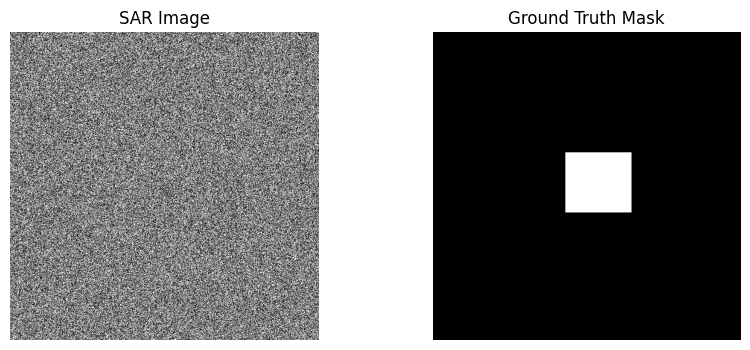

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("SAR Image")
plt.imshow(sar_image, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Ground Truth Mask")
plt.imshow(mask, cmap='gray')
plt.axis("off")

plt.show()


Min pixel: 0
Max pixel: 254


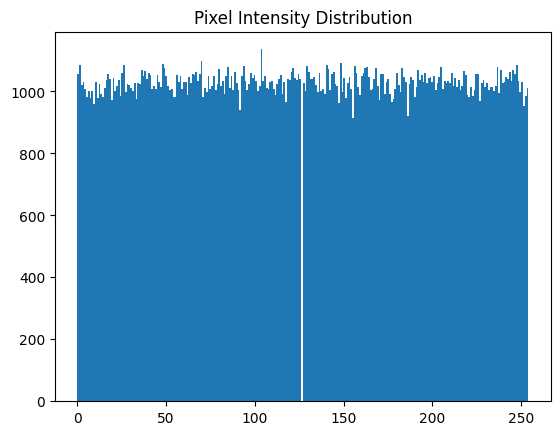

In [ ]:
print("Min pixel:", sar_image.min())
print("Max pixel:", sar_image.max())

plt.hist(sar_image.flatten(), bins=256)
plt.title("Pixel Intensity Distribution")
plt.show()


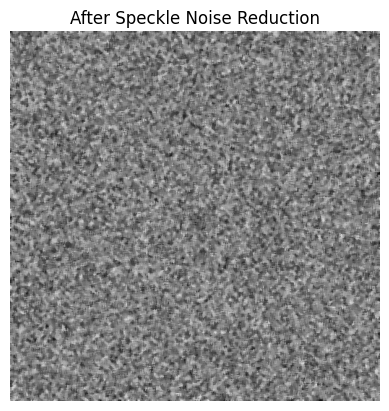

In [ ]:
denoised = cv2.medianBlur(sar_image, 5)

plt.imshow(denoised, cmap='gray')
plt.title("After Speckle Noise Reduction")
plt.axis("off")
plt.show()


In [ ]:
IMG_SIZE = 256

img_resized = cv2.resize(denoised, (IMG_SIZE, IMG_SIZE))
mask_resized = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

img_norm = img_resized / 255.0
mask_norm = mask_resized / 255.0

print(img_norm.shape, mask_norm.shape)


(256, 256) (256, 256)


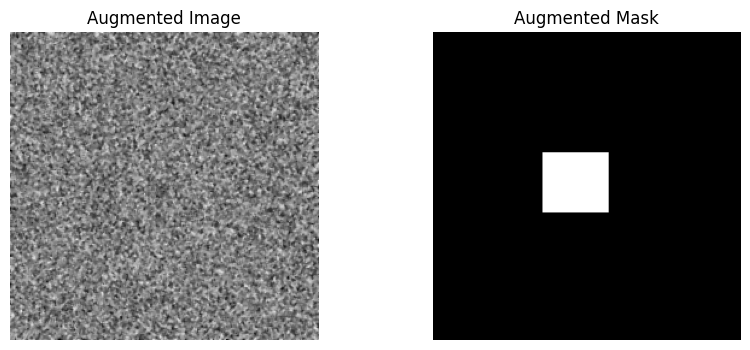

In [ ]:
augmenter = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.4)
])

aug = augmenter(image=img_norm, mask=mask_norm)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Augmented Image")
plt.imshow(aug["image"], cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Augmented Mask")
plt.imshow(aug["mask"], cmap='gray')
plt.axis("off")
plt.show()


In [ ]:
# Module 3: Model Development (Segmentation)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K


In [ ]:
def dice_loss(y_true, y_pred):
    smooth = 1
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2 * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


In [ ]:
def build_unet():
    inputs = layers.Input((256,256,1))

    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)

    u1 = layers.UpSampling2D()(c2)
    m1 = layers.concatenate([u1, c1])

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(m1)

    return models.Model(inputs, outputs)

model = build_unet()
model.compile(optimizer='adam', loss=dice_loss, metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 256, 256,  │          0 │ conv2d_1[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │         97 │ concatenate[0][0] │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,913 (73.88 KB)

 Trainable params: 18,913 (73.88 KB)

 Non-trainable params: 0 (0.00 B)

Module 4: Training and Evaluation

In [ ]:
# Module 4: Training and Evaluation


In [ ]:
X = img_norm[np.newaxis, ..., np.newaxis]
Y = mask_norm[np.newaxis, ..., np.newaxis]


In [ ]:
model.fit(X, Y, epochs=5)


Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.0461 - loss: 0.9224
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.0420 - loss: 0.9222
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.0420 - loss: 0.9221
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.0420 - loss: 0.9220
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.0420 - loss: 0.9218


In [ ]:
pred = model.predict(X)[0,:,:,0]
pred_bin = (pred > 0.5).astype(np.uint8)

intersection = np.logical_and(mask_norm, pred_bin).sum()
union = np.logical_or(mask_norm, pred_bin).sum()
iou = intersection / (union + 1e-7)

print("IoU:", iou)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
IoU: 0.04196166992181097


# Module 5: Visualization of Results


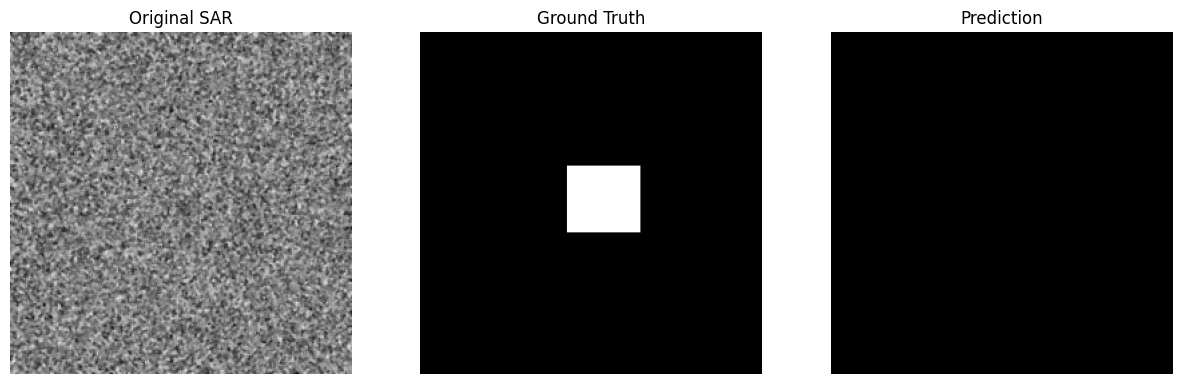

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original SAR")
plt.imshow(img_norm, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask_norm, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred_bin, cmap='gray')
plt.axis("off")

plt.show()


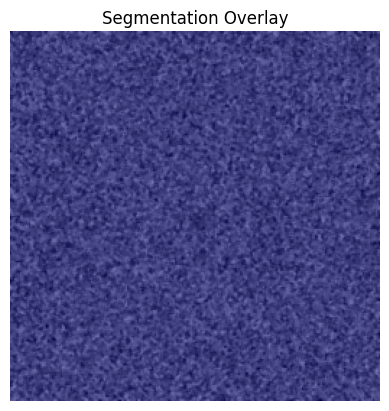

In [ ]:
plt.imshow(img_norm, cmap='gray')
plt.imshow(pred_bin, cmap='jet', alpha=0.5)
plt.title("Segmentation Overlay")
plt.axis("off")
plt.show()


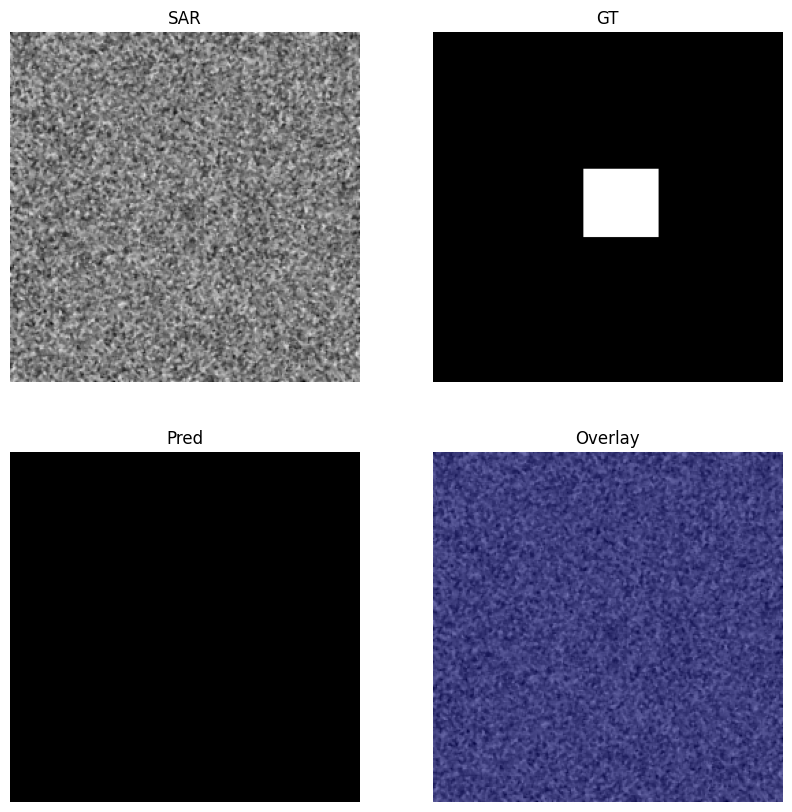

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(10,10))

axs[0,0].imshow(img_norm, cmap='gray'); axs[0,0].set_title("SAR")
axs[0,1].imshow(mask_norm, cmap='gray'); axs[0,1].set_title("GT")
axs[1,0].imshow(pred_bin, cmap='gray'); axs[1,0].set_title("Pred")
axs[1,1].imshow(img_norm, cmap='gray'); axs[1,1].imshow(pred_bin, cmap='jet', alpha=0.5)
axs[1,1].set_title("Overlay")

for ax in axs.flat:
    ax.axis("off")

plt.show()
